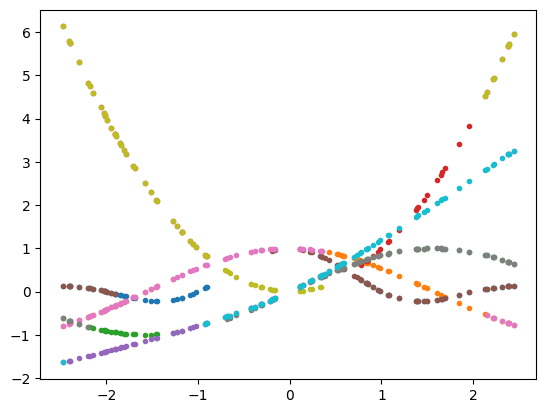

In [208]:
from matplotlib import pyplot as plt
import numpy as np
import torch


# Define the activation functions
def sin_activation(x):
    return np.sin(x)

def square_activation(x):
    return x**2

def bent_activation(x):
    return (np.sqrt(x ** 2 + 1) - 1) / 2 + x

def cos_activation(x):
    return np.cos(x)

def sinc_activation(x):
    return np.sinc(x)

task_list = [
    sinc_activation,
    cos_activation,
    sin_activation,
    square_activation,
    bent_activation,
] * 2

input_dim = 1
extrapolate = False
full_tasks = []

# generate data
np.random.seed(0)
x_train = (np.random.rand(100, input_dim) - 0.5) * 5.0
x_valid = (np.random.rand(100, input_dim) - 0.5) * 5.0

delta_mag = 0.0

y_train = np.zeros([x_train.shape[0], 0])
y_valid = np.zeros([x_valid.shape[0], 0])
for task in task_list:
    y_train = np.hstack([y_train, task(x_train) + np.random.randn(x_train.shape[0], x_train.shape[1]) * delta_mag])
    y_valid = np.hstack([y_valid, task(x_valid) + np.random.randn(x_valid.shape[0], x_valid.shape[1]) * delta_mag])

missing_frac = 0.33
for i, _ in enumerate(task_list):
    np.random.seed(i)
    if extrapolate:
        if np.random.rand() < 0.5:
            lo_pct = 0  # start at left boundary
        else:
            lo_pct = 1 - missing_frac  # start at right boundary
    else:
        lo_pct = np.random.rand() * (1-missing_frac)
    hi_pct = lo_pct + missing_frac
    lo, hi = np.percentile(x_train, [lo_pct*100, hi_pct*100])
    x_in = (x_train >= lo) & (x_train <= hi)
    if i in full_tasks:
        x_in = np.zeros(0, dtype=bool)
    y_train[x_in.flatten(), i] = np.nan

x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).float()

x_valid = torch.tensor(x_valid).float()
y_valid = torch.tensor(y_valid).float()

for i in range(y_train.shape[1]):
    plt.plot(x_train, y_train[:, i], '.')

In [234]:
from torch import nn
import torch.nn.functional as F
import hyperlight as hl


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU()):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.activation = activation

        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dims[0]))
        for i in range(1, len(hidden_dims)):
            self.layers.append(nn.Linear(hidden_dims[i - 1], hidden_dims[i]))
        self.layers.append(nn.Linear(hidden_dims[-1], output_dim))

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x


class TaskEncoder(nn.Module):
    def __init__(self, num_tasks, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_tasks, embedding_dim)
        self.encoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
    
    def forward(self, task_id):
        initial_embedding = self.embedding(task_id)
        return self.encoder(initial_embedding)


class HyperMLP(nn.Module):
    def __init__(self, num_tasks, embedding_dim=4, hidden_dim=4):
        super().__init__()
        self.task_embeddings = nn.Embedding(num_tasks, embedding_dim)
        # self.task_embeddings = TaskEncoder(num_tasks, embedding_dim, hidden_dim)    
    
        # mainnet = MLP(1, (8, 8, ), 1)
        # modules = hl.find_modules_of_type(mainnet, [nn.Linear])
        mainnet = sparsenn.RegularizedMLPwithSkips(1, (8, ), 1, activation=nn.ReLU())
        modules = hl.find_modules_of_type(mainnet, [sparsenn.L0Linear])
        self.mainnet = hl.hypernetize(mainnet, modules=modules)
        parameter_shapes = self.mainnet.external_shapes()
        self.hypernet = hl.HyperNet(
                input_shapes={'h': (embedding_dim,)},
                output_shapes=parameter_shapes,
                hidden_sizes=[32, 32, ],
            )
        
    def forward(self, main_input, task_id):
        h = self.task_embeddings(task_id)
        h = F.sigmoid( h )
        
        parameters = self.hypernet(h=h)

        with self.mainnet.using_externals(parameters):
            prediction = self.mainnet(main_input)

        return prediction

    def regularization_loss(self, task_id):
        h = self.task_embeddings(task_id)
        h = F.sigmoid( h )
        
        parameters = self.hypernet(h=h)
        with self.mainnet.using_externals(parameters):
            reg_loss = self.mainnet.regularization_loss()
        
        return reg_loss

# Usage
model = HyperMLP(num_tasks=len(task_list), embedding_dim=len(task_list))
for i, _ in enumerate(task_list):
    task_id = torch.tensor([i])  # Assuming task IDs are 0-indexed
    print(model(x_train, task_id).shape)

torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])
torch.Size([100, 1])


In [235]:
import sparsenn
from torch import optim
from copy import deepcopy

criterion = sparsenn.MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

max_epochs = int(1e6)
patience_interval = 1000
last_best = (0, np.inf)
best_model = deepcopy(model)

lmbda = 1e-7

model.train()
for epoch in range(max_epochs):
    total_loss = 0.
    total_regl = 0.
    for i, task in enumerate(task_list):
        optimizer.zero_grad()
        outputs = model(x_train, torch.tensor([i]))
        loss = criterion(outputs, y_train[:, [i]]) + lmbda * model.regularization_loss(torch.tensor([i]))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if total_loss < last_best[1]:
        last_best = (epoch, total_loss)
        best_model = deepcopy(model)

    if (epoch+1) % 100 == 0:
        with torch.no_grad():
            total_valid_loss = 0.
            task_reg = []
            for i, task in enumerate(task_list):
                outputs = model(x_valid, torch.tensor([i]))
                valid_loss = criterion(outputs, y_valid[:, [i]])
                total_valid_loss += valid_loss.item()
                task_reg.append( model.regularization_loss(torch.tensor([i])).item() )
        print(f'Epoch {epoch+1}, MSE: {total_loss:.4f}, ValMSE: {total_valid_loss:.4f}, Task Reg. {[int(it) for it in task_reg]}')
    
    if epoch - last_best[0] > patience_interval:
        print('Patience expired...')
        break
        
model = best_model        

Epoch 100, MSE: 3.8819, ValMSE: 5.0684, Task Reg. [14, 13, 12, 13, 12, 13, 13, 13, 12, 13]
Epoch 200, MSE: 1.0234, ValMSE: 1.4533, Task Reg. [13, 12, 12, 12, 11, 12, 13, 12, 12, 12]
Epoch 300, MSE: 1.1202, ValMSE: 1.1805, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 400, MSE: 0.9555, ValMSE: 1.2182, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 500, MSE: 0.3360, ValMSE: 0.7700, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 600, MSE: 0.3295, ValMSE: 0.7942, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 700, MSE: 0.2776, ValMSE: 0.7498, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 800, MSE: 1.1612, ValMSE: 1.3702, Task Reg. [12, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 900, MSE: 0.5619, ValMSE: 0.6756, Task Reg. [13, 12, 11, 11, 11, 12, 12, 11, 11, 12]
Epoch 1000, MSE: 0.2152, ValMSE: 0.6208, Task Reg. [13, 12, 11, 12, 11, 12, 12, 11, 12, 12]
Epoch 1100, MSE: 0.1986, ValMSE: 0.5924, Task Reg. [13, 12, 11, 12, 11, 12, 12, 11, 12, 1

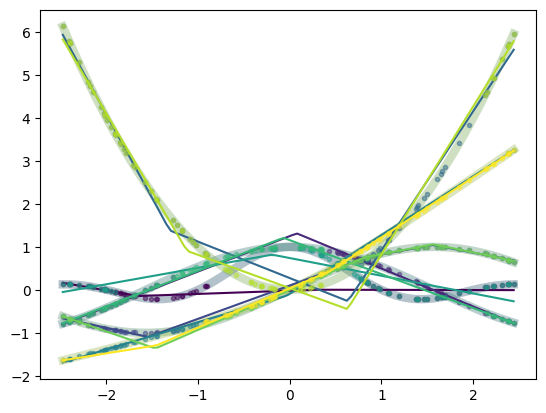

In [236]:
from matplotlib import cm

model.eval()

x_arr = torch.linspace(x_train.min(), x_train.max(), 101)
idx = np.argsort(x_train.numpy().flatten())
colors = cm.viridis(np.linspace(0, 1, y_train.shape[1]))
for i in range(y_train.shape[1]):
    with torch.no_grad():
        output = model(x_arr.unsqueeze(1), torch.tensor([i]))
    plt.plot(x_train[idx], y_train[idx, i], '.', c=colors[i], alpha=0.5)
    plt.plot(x_arr, output.numpy(), '-', c=colors[i])
    plt.plot(x_arr, task_list[i](x_arr), '-', c=colors[i], lw=6, alpha=0.2, zorder=-1)